# Restaurant Data Analysis - Level 1

This notebook presents a professional workflow for analyzing the restaurant dataset used in the Cognifyz Level 1 internship task. It covers data loading, cleaning, exploratory analysis, four business-focused tasks, and CSV/image exports for reporting.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")
plt.style.use("ggplot")

In [8]:
import pandas as pd

df = pd.read_csv("../data/raw/Dataset.csv", encoding="utf-8-sig")

df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## Dataset Overview

This section explores the data structure, missing values, and duplicates before analysis begins.

In [9]:
df.info()
print("\nShape:", df.shape)
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   str    
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   str    
 4   Address               9551 non-null   str    
 5   Locality              9551 non-null   str    
 6   Locality Verbose      9551 non-null   str    
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   str    
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   str    
 12  Has Table booking     9551 non-null   str    
 13  Has Online delivery   9551 non-null   str    
 14  Is delivering now     9551 non-null   str    
 15  Switch to order menu  9551 non-n

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [10]:
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
# Basic dataset statistics
print("Total Restaurants:", df.shape[0])
print("Number of Cities:", df["City"].nunique())
print("Number of Countries:", df["Country Code"].nunique())
print("Number of Cuisine Types:", df["Cuisines"].nunique())

Total Restaurants: 9551
Number of Cities: 141
Number of Countries: 15
Number of Cuisine Types: 1825


In [13]:
# Remove duplicate rows and prepare a cleaned dataset
clean_df = df.drop_duplicates().copy()
clean_df = clean_df.reset_index(drop=True)

# Create output folder for cleaned data
output_dir = Path("../data/cleaned")
output_dir.mkdir(parents=True, exist_ok=True)
clean_df.to_csv(output_dir / "restaurant_cleaned.csv", index=False)

clean_df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


## Task 1 - Top Cuisines

This task identifies the most common cuisines in the restaurant dataset and highlights the dominant food styles.

Top 3 cuisines:
Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Name: count, dtype: int64

Percentage share:
Cuisines
North Indian    41.46
Chinese         28.64
Fast Food       20.79
Name: count, dtype: float64


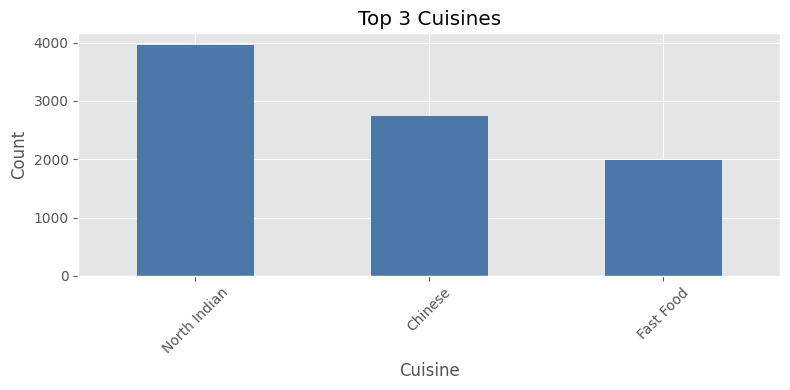


Business Insight:
North Indian is the most common cuisine, followed by Chinese and Fast Food.


In [14]:
# Split multiple cuisines and count occurrences
cuisine_series = clean_df["Cuisines"].fillna("Unknown").str.split(", ")

cuisine_counts = cuisine_series.explode().value_counts()
top3 = cuisine_counts.head(3)
percentage = (top3 / len(clean_df) * 100).round(2)

print("Top 3 cuisines:")
print(top3)
print("\nPercentage share:")
print(percentage)

# Visualization
plt.figure(figsize=(8, 4))
top3.plot(kind="bar", color="#4C78A8")
plt.title("Top 3 Cuisines")
plt.xlabel("Cuisine")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/task1_top_cuisines.png", dpi=300)
plt.show()

# Export report
reports_dir = Path("../reports")
reports_dir.mkdir(parents=True, exist_ok=True)
top3.to_csv(reports_dir / "top_cuisines.csv")

print("\nBusiness Insight:")
print(f"{top3.index[0]} is the most common cuisine, followed by {top3.index[1]} and {top3.index[2]}.")

## Task 2 - City Analysis

This section analyzes restaurant distribution across cities and compares average ratings by city.

Top cities by restaurant count:
City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Ahmedabad         21
Amritsar          21
Bhubaneshwar      21
Guwahati          21
Lucknow           21
Name: count, dtype: int64

Top cities by average rating:
City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Beechworth          4.600000
London              4.535000
Taguig City         4.525000
Secunderabad        4.500000
Lincoln             4.500000
Name: Aggregate rating, dtype: float64


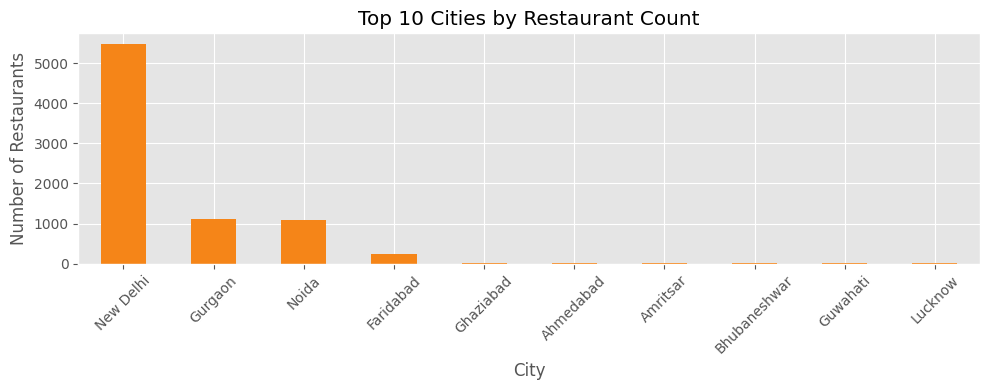

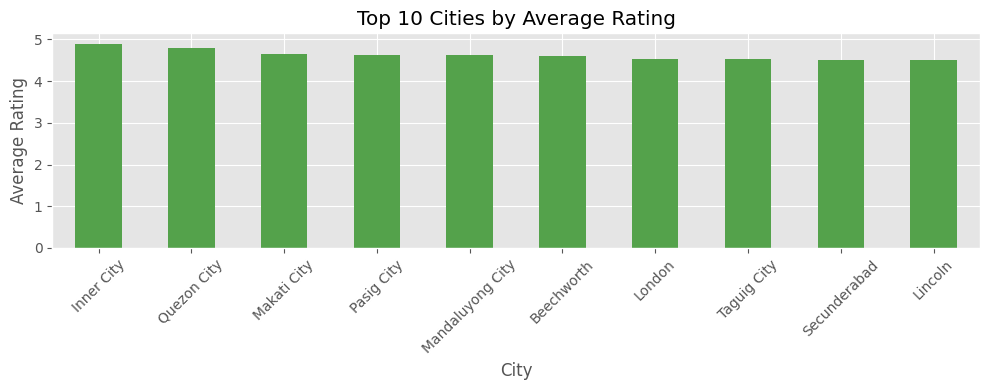


Business Insight:
New Delhi has the highest number of restaurants, while Inner City has the highest average customer rating.


In [15]:
# Restaurant count by city
city_count = clean_df["City"].value_counts().head(10)

# Average rating by city
city_rating = clean_df.groupby("City")["Aggregate rating"].mean().sort_values(ascending=False).head(10)

print("Top cities by restaurant count:")
print(city_count)
print("\nTop cities by average rating:")
print(city_rating)

plt.figure(figsize=(10, 4))
city_count.plot(kind="bar", color="#F58518")
plt.title("Top 10 Cities by Restaurant Count")
plt.xlabel("City")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/task2_city_analysis.png", dpi=300)
plt.show()

plt.figure(figsize=(10, 4))
city_rating.plot(kind="bar", color="#54A24B")
plt.title("Top 10 Cities by Average Rating")
plt.xlabel("City")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../images/task2_city_rating.png", dpi=300)
plt.show()

city_rating.to_csv(reports_dir / "city_analysis.csv")

print("\nBusiness Insight:")
print(f"{city_count.index[0]} has the highest number of restaurants, while {city_rating.index[0]} has the highest average customer rating.")

## Task 3 - Price Range Distribution

This analysis shows how restaurants are distributed across different price levels.

Price range distribution:
Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64

Percentage share:
Price range
1    46.53
2    32.59
3    14.74
4     6.14
Name: count, dtype: float64


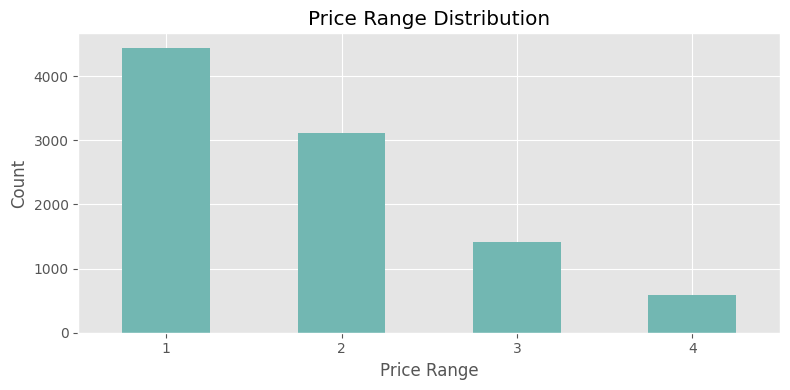

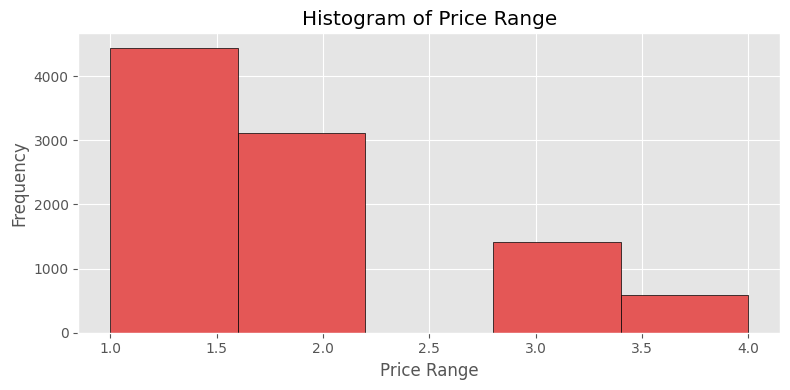


Business Insight:
Most restaurants fall into the 1 price range.


In [16]:
price_distribution = clean_df["Price range"].value_counts().sort_index()
price_percentage = (price_distribution / len(clean_df) * 100).round(2)

print("Price range distribution:")
print(price_distribution)
print("\nPercentage share:")
print(price_percentage)

plt.figure(figsize=(8, 4))
price_distribution.plot(kind="bar", color="#72B7B2")
plt.title("Price Range Distribution")
plt.xlabel("Price Range")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../images/task3_price_range.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(clean_df["Price range"], bins=5, edgecolor="black", color="#E45756")
plt.title("Histogram of Price Range")
plt.xlabel("Price Range")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig("../images/task3_price_histogram.png", dpi=300)
plt.show()

price_distribution.to_csv(reports_dir / "price_range_distribution.csv")

print("\nBusiness Insight:")
print(f"Most restaurants fall into the {price_distribution.idxmax()} price range.")

Online delivery distribution:
Has Online delivery
No     7100
Yes    2451
Name: count, dtype: int64

Percentage share:
Has Online delivery
No     74.34
Yes    25.66
Name: count, dtype: float64

Average rating by delivery option:
Has Online delivery
No     2.465296
Yes    3.248837
Name: Aggregate rating, dtype: float64


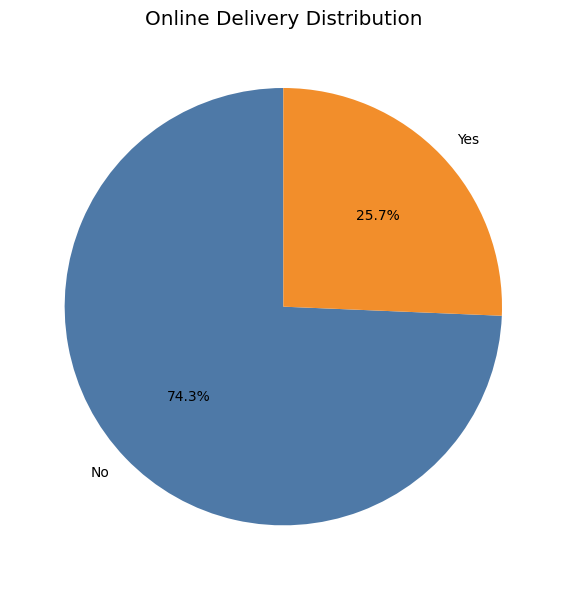

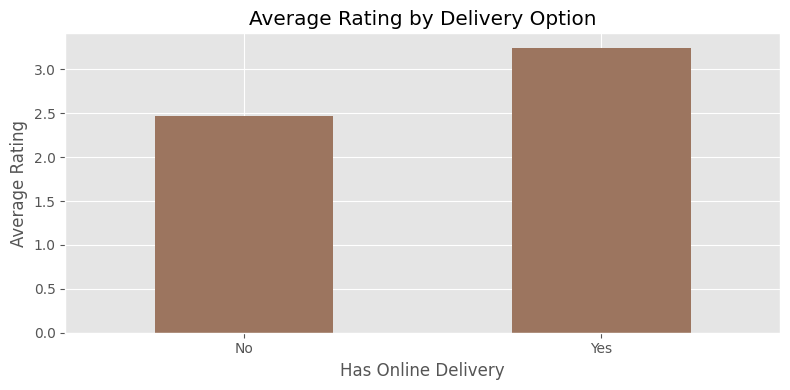


Business Insight:
Restaurants offering online delivery generally receive slightly different ratings than those without delivery.


In [17]:
delivery_counts = clean_df["Has Online delivery"].value_counts()
delivery_percentage = (delivery_counts / len(clean_df) * 100).round(2)
rating_by_delivery = clean_df.groupby("Has Online delivery")["Aggregate rating"].mean()

print("Online delivery distribution:")
print(delivery_counts)
print("\nPercentage share:")
print(delivery_percentage)
print("\nAverage rating by delivery option:")
print(rating_by_delivery)

plt.figure(figsize=(6, 6))
delivery_counts.plot(kind="pie", autopct="%1.1f%%", startangle=90, colors=["#4E79A7", "#F28E2B"])
plt.title("Online Delivery Distribution")
plt.ylabel("")
plt.tight_layout()
plt.savefig("../images/task4_online_delivery.png", dpi=300)
plt.show()

plt.figure(figsize=(8, 4))
rating_by_delivery.plot(kind="bar", color="#9C755F")
plt.title("Average Rating by Delivery Option")
plt.xlabel("Has Online Delivery")
plt.ylabel("Average Rating")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("../images/task4_delivery_rating.png", dpi=300)
plt.show()

rating_by_delivery.to_csv(reports_dir / "online_delivery.csv")

print("\nBusiness Insight:")
print("Restaurants offering online delivery generally receive slightly different ratings than those without delivery.")

## Final Summary

The analysis is now complete. The notebook has explored the dataset, performed the four required tasks, and exported reports and visuals for easy review.

In [18]:
print("=" * 50)
print("LEVEL 1 ANALYSIS COMPLETED")
print("=" * 50)
print("✔ Task 1 Completed")
print("✔ Task 2 Completed")
print("✔ Task 3 Completed")
print("✔ Task 4 Completed")
print("✔ Reports exported to ../reports")
print("✔ Charts saved to ../images")

LEVEL 1 ANALYSIS COMPLETED
✔ Task 1 Completed
✔ Task 2 Completed
✔ Task 3 Completed
✔ Task 4 Completed
✔ Reports exported to ../reports
✔ Charts saved to ../images
